**Predicting Student Mental Health Score from Social Media Usage**

**Problem:** We're predicting a student's Mental_Health_Score (a continuous score from ~3 to ~10) using their social media habits, study time, sleep, physical activity, and stress level. This is a regression problem since the target is a number, not a category.

**Dataset:** Student_Social_Media_And_Mental_Health_Impact.csv — 5,000 students, 13 columns covering demographics (Age, Gender, Country), platform usage (Avg_Daily_Usage_Hours, Daily_Unlocks, Most_Used_Platform), lifestyle (Study_Hours, Sleep_Hours_Per_Night, Physical_Activity_Hours), and Stress_Level.

[Know more about Data](https://www.kaggle.com/datasets/shivasingh4945/student-social-media-and-mental-health-impact)

Importing libraries

In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

Loading the dataset

In [ ]:
df = pd.read_csv("data/Student_Social_Media_And_Mental_Health_Impact.csv")
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


Basic exploration

In [52]:
df.shape

(5000, 13)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [54]:
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [55]:
df.duplicated().sum()

np.int64(2)

In [56]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


the dataset has 5000 rows and 13 columns, no null values but 2 duplicate rows. No type conversions needed. Mental health is the target column ranging from 3 - 10 with 9.4 as a the maximum value(as in dataset). In physical activity hrs there are few negative values

**EDA**

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

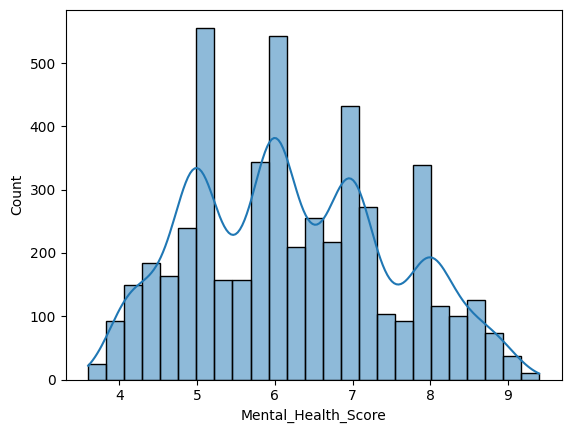

In [57]:
# target distribution

sns.histplot(df['Mental_Health_Score'],kde = True)

<Axes: >

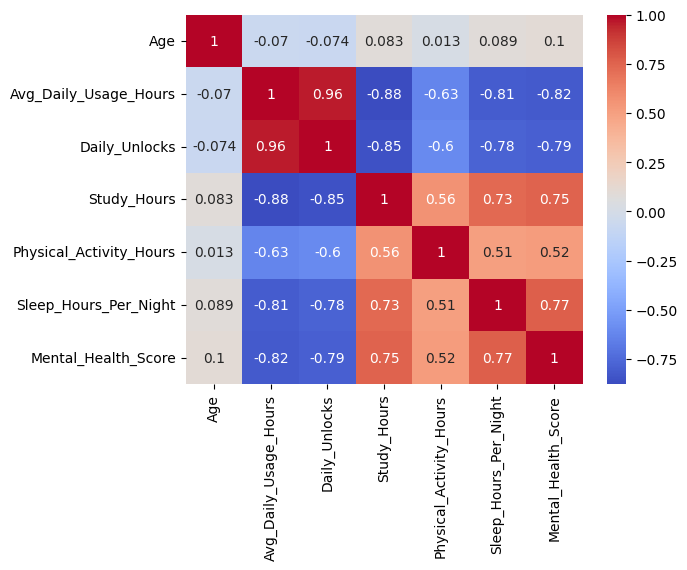

In [58]:
# correlation

#only possible for numeric cols
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

In [59]:
# stress level vs mental health score

df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

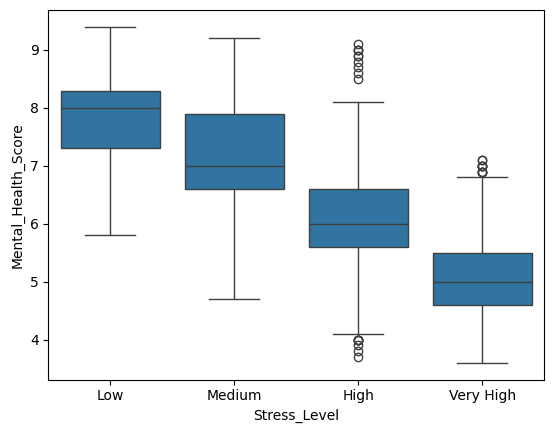

In [60]:
order = ['Low', 'Medium', 'High', 'Very High']
sns.boxplot(x = 'Stress_Level', y='Mental_Health_Score',data = df,order = order)

by this plot we can conclude that High stress is giving lower mental health score but there are some outliters too

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

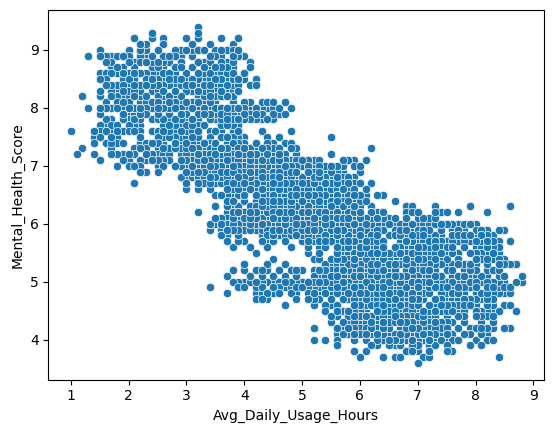

In [61]:
# daily usage vs mental health

sns.scatterplot(x='Avg_Daily_Usage_Hours',y='Mental_Health_Score', data = df)

By this plot we can conclude that as the daily usage hrs increase mental health score decrease they are negatively co related (already shown in heatmap)

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

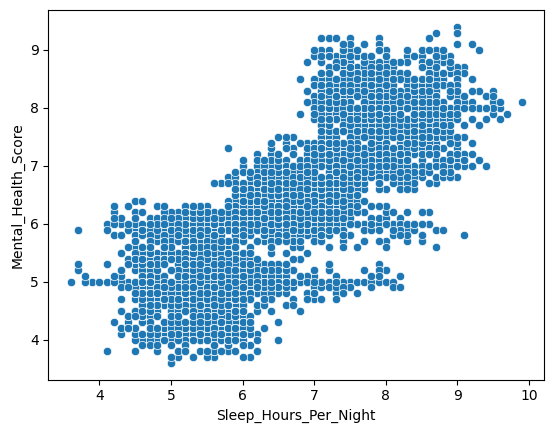

In [62]:
#sleep hrs vs mental health

sns.scatterplot(x='Sleep_Hours_Per_Night',y='Mental_Health_Score',data = df)

From this plot we can see that sleep hrs is directly correlated to mental health score. people who sleep more have better score

<Axes: xlabel='Most_Used_Platform', ylabel='count'>

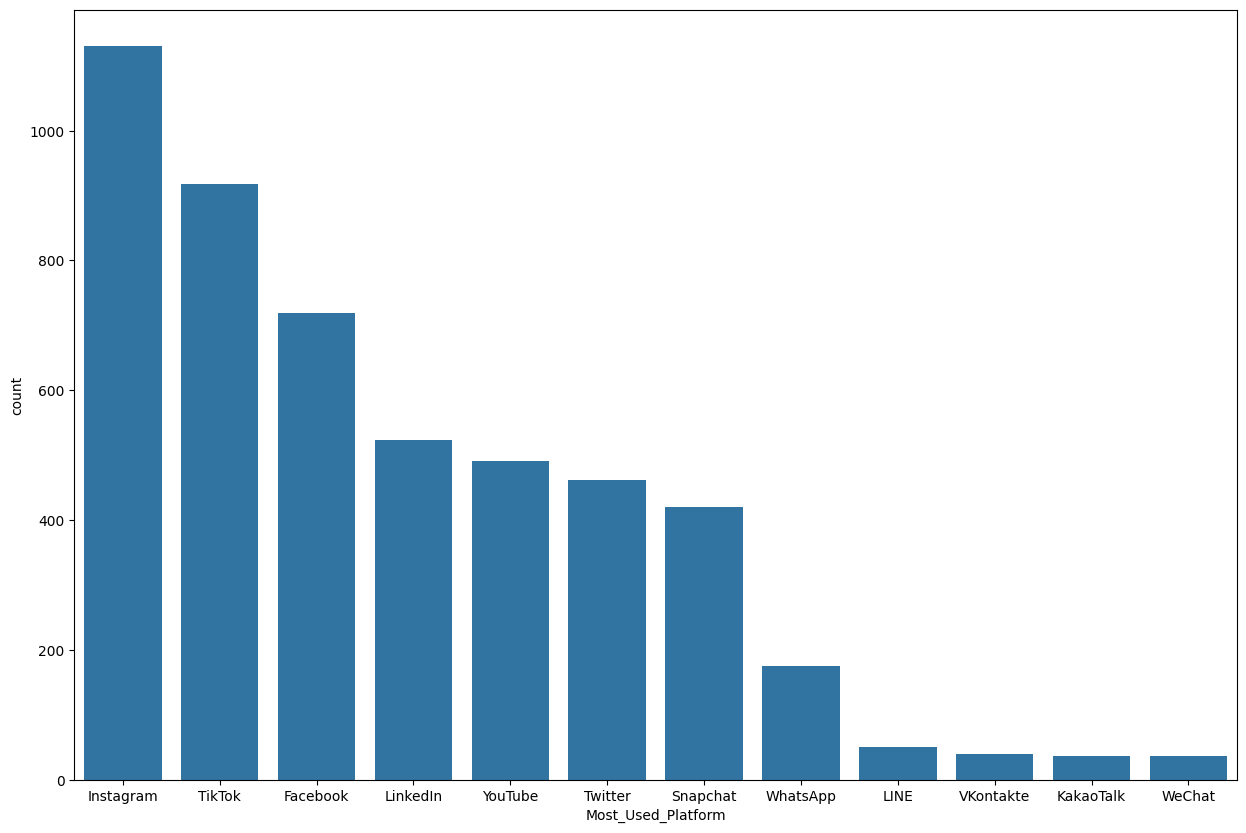

In [63]:
# most used platform
plt.figure(figsize=(15, 10))
sns.countplot(x='Most_Used_Platform',data = df, order = df['Most_Used_Platform'].value_counts().index)

Outliers check

In [64]:
num_features = df.select_dtypes(include='number')
num_features

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
0,21,4.0,134,4.5,2.2,6.7,6.8
1,23,1.6,73,7.0,2.4,8.6,7.6
2,22,4.6,166,4.0,1.8,6.7,7.0
3,18,7.0,220,1.0,1.7,5.4,5.3
4,24,7.5,237,1.0,1.1,5.0,4.4
...,...,...,...,...,...,...,...
4995,18,1.9,89,6.1,2.2,7.9,7.9
4996,18,6.6,216,2.3,1.8,6.0,4.7
4997,19,3.8,151,5.4,1.4,7.5,7.0
4998,18,3.8,119,4.0,1.5,6.4,6.7


In [65]:
Q1 = num_features.quantile(0.25)
Q3 = num_features.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (num_features < lower_bound) | (num_features > upper_bound)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


Data Cleaning

In [66]:
df = df.drop_duplicates()

In [67]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.750760,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.668406,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [68]:
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)

In [69]:
df.shape

(4998, 13)

In [70]:
# skewed

num_features.skew()

,0
Age,0.155325
Avg_Daily_Usage_Hours,0.005606
Daily_Unlocks,0.002351
Study_Hours,0.435819
Physical_Activity_Hours,0.039971
Sleep_Hours_Per_Night,0.124050
Mental_Health_Score,0.206567


study_hrs column is highly right skewed can be fixed by log transformations

**Feature Engg**

In [71]:
top_countries = df['Country'].value_counts().index[:10].to_list()

In [72]:
def group_countries(country):
  if country in top_countries:
    return country
  else:
    return 'Other'

In [73]:
df['Grouped_country'] = df['Country'].apply(group_countries)

In [74]:
df['Grouped_country'].value_counts()

,count
Grouped_country,
Other,3231
India,389
USA,354
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94
Turkey,94


After one hot encoding instead of creating many cols this method creates just 11 cols

**Encoding**

Stress_level -> ordinal

Gender, Academic_level, Most_used_platform,Purpose_of_use, Grouped_country -> Onehot

**Train Test Split**

In [75]:
# We split before any preprocesing to avoid data leakage

In [76]:
skewed_cols = ['Study_Hours']
other_num_cols = ['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
        'Physical_Activity_Hours', 'Sleep_Hours_Per_Night']
ordinal_col = ['Stress_Level']
normal_col = ["Gender", "Academic_Level", "Most_Used_Platform", "Purpose_Of_Use", "Grouped_country"]

feature_col = skewed_cols + other_num_cols + ordinal_col + normal_col

In [77]:
X = df[feature_col]
y = df['Mental_Health_Score']

In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.30, random_state = 42)

Prepocessing

In [79]:
# Pipelines for Column Transformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder

#skew
skew_pipeline = Pipeline(steps=[
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scaler',StandardScaler())
])

# plain numeric
plain_num_pipeline = Pipeline(steps=[
    ('scaler',StandardScaler())
])

# Ordinal
ordinal_pipeline = Pipeline(steps = [
    ('encoder',OrdinalEncoder(categories = [['Low','Medium','High','Very High']]))
])

# Nominal
nominal_pipeline = Pipeline(steps = [
    ('encoder', OneHotEncoder(handle_unknown = 'ignore'))
])



In [80]:
from sklearn.compose import ColumnTransformer

# name- pipeline - cols
preprocessor = ColumnTransformer(transformers = [
    ("Skewed_Pipeline",skew_pipeline, skewed_cols),
    ("Numerical_Pipeline",plain_num_pipeline, other_num_cols),
    ("Ordinal_Pipeline",ordinal_pipeline, ordinal_col),
    ("Nominal_Pipeline",nominal_pipeline, normal_col)
])

**Model Building**

In [81]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_preds       = lr_pipeline.predict(X_test)
lr_preds_train = lr_pipeline.predict(X_train)

lr_r2_testing  = r2_score(y_test, lr_preds)
lr_r2_training = r2_score(y_train, lr_preds_train)
lr_mae         = mean_absolute_error(y_test, lr_preds)
lr_mse         = mean_squared_error(y_test,lr_preds)

print(f"Accuracy of Training {lr_r2_training}")
print(f"Accuracy of Testing {lr_r2_testing}")
print(f'MAE {lr_mae}')
print(f'MSE {lr_mse}')

Accuracy of Training 0.7236771199387538
Accuracy of Testing 0.7397944617433021
MAE 0.5361775634720181
MSE 0.45701905273487986


Though Testing accuracy is more important we also check training accuracy to understand if the model is overfitting

training acc >> testing acc -> overfitting

for LR Model we got similar training and testing accuracy

In [82]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(random_state=42),
    "Lasso Regression": Lasso(random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR()
}

results = []

for name, model in models.items():

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predictions
    train_preds = pipeline.predict(X_train)
    test_preds = pipeline.predict(X_test)

    # Metrics
    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)
    mae = mean_absolute_error(y_test, test_preds)
    mse = mean_squared_error(y_test, test_preds)
    rmse = root_mean_squared_error(y_test, test_preds)

    results.append({
        "Model": name,
        "Train R²": train_r2,
        "Test R²": test_r2,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse
    })

In [83]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="Test R²", ascending=False)

print(results_df)

               Model  Train R²   Test R²       MAE       MSE      RMSE
4      Random Forest  0.980829  0.877589  0.347221  0.215000  0.463681
6                KNN  0.890600  0.840021  0.383587  0.280983  0.530078
7                SVR  0.826412  0.807174  0.436103  0.338675  0.581958
5  Gradient Boosting  0.812944  0.799062  0.465402  0.352922  0.594073
3      Decision Tree  0.999992  0.747716  0.426800  0.443107  0.665663
1   Ridge Regression  0.723672  0.739874  0.536054  0.456880  0.675929
0  Linear Regression  0.723677  0.739794  0.536178  0.457019  0.676032
2   Lasso Regression  0.029061  0.026707  1.098083  1.709469  1.307467


Random forest gave better results than other model so we tune Random Forest to get more better predictions

For Random forest model we got higher training accuracy nd lower testing accuracy -> overfitting

we can reduce the overfitting by tuning its hyper parameters

**Hyper Parameter Tuning**

In [84]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('random forest', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_preds          = rf_pipeline.predict(X_test)
rf_preds_training = rf_pipeline.predict(X_train)

rf_r2_testing  = r2_score(y_test, rf_preds)
rf_r2_training = r2_score(y_train, rf_preds_training)
rf_mae         = mean_absolute_error(y_test, rf_preds)

print(f"Accuracy of Training {rf_r2_training}")
print(f"Accuracy of Testing {rf_r2_testing}")
print(f"MAE : {rf_mae}")

Accuracy of Training 0.9808287942404612
Accuracy of Testing 0.8775888638668996
MAE : 0.34722113333333343


First tune

In [85]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'random forest__n_estimators'       : [100,200,300],
    'random forest__max_depth'         : [5,10,15],
    'random forest__min_samples_split' : [2,5,10],
    'random forest__min_samples_leaf'  : [1,2,4]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter = 15,
    cv = 5,
    scoring='r2',
    random_state=42,
    n_jobs =-1 #processor free
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('Skewed_Pipeline',
                                                                               Pipeline(steps=[('log_transform',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('Numerical_Pipeline',
                                                                               Pipeline(steps=[('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Avg_Daily_Usage_Hours',
                                                                                'Daily_Unloc...
                                                                                'Most_Used_Platform',
                                                                                'Purpose_Of_Use',
                                                                                'Grouped_country'])])),
                                             ('random forest',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'random forest__max_depth': [5, 10, 15],
                                        'random forest__min_samples_leaf': [1,
                                                                            2,
                                                                            4],
                                        'random forest__min_samples_split': [2,
                                                                             5,
                                                                             10],
                                        'random forest__n_estimators': [100,
                                                                        200,
                                                                        300]},
                   random_state=42, scoring='r2')

In [86]:
random_search.best_params_

{'random forest__n_estimators': 200,
 'random forest__min_samples_split': 5,
 'random forest__min_samples_leaf': 2,
 'random forest__max_depth': 15}

In [87]:
rf_first_pipeline = random_search.best_estimator_
rf_first_preds = rf_first_pipeline.predict(X_test)
rf_first_preds_train = rf_first_pipeline.predict(X_train)

rf_first_r2_testing  = r2_score(y_test, rf_first_preds)
rf_first_r2_training = r2_score(y_train, rf_first_preds_train)
rf_first_mae         = mean_absolute_error(y_test, rf_first_preds)

print(f"Accuracy of Training {rf_first_r2_training}")
print(f"Accuracy of Testing {rf_first_r2_testing}")
print(f"MAE : {rf_first_mae}")

Accuracy of Training 0.9547027344112449
Accuracy of Testing 0.8650140569761653
MAE : 0.3689015766630922


Here the overfitting is less but the testing accuracy dropped and the mae increased. The default model was performing better than this tuned model

Second Tuning (increasing the search space)

In [88]:
param_dist = {
    'random forest__n_estimators':[100,200,300,500],
    'random forest__max_depth':[None,10,20,30,40],
    'random forest__min_samples_split':[2,5,10],
    'random forest__min_samples_leaf':[1,2,4],
    'random forest__max_features':['sqrt','log2',None]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter = 15,
    cv = 5,
    scoring='r2',
    random_state=42,
    n_jobs =-1
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('Skewed_Pipeline',
                                                                               Pipeline(steps=[('log_transform',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('Numerical_Pipeline',
                                                                               Pipeline(steps=[('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Avg_Daily_Usage_Hours',
                                                                                'Daily_Unloc...
                                             ('random forest',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'random forest__max_depth': [None, 10,
                                                                     20, 30,
                                                                     40],
                                        'random forest__max_features': ['sqrt',
                                                                        'log2',
                                                                        None],
                                        'random forest__min_samples_leaf': [1,
                                                                            2,
                                                                            4],
                                        'random forest__min_samples_split': [2,
                                                                             5,
                                                                             10],
                                        'random forest__n_estimators': [100,
                                                                        200,
                                                                        300,
                                                                        500]},
                   random_state=42, scoring='r2')

In [89]:
random_search.best_params_

{'random forest__n_estimators': 200,
 'random forest__min_samples_split': 2,
 'random forest__min_samples_leaf': 1,
 'random forest__max_features': 'log2',
 'random forest__max_depth': 40}

In [90]:
rf_second_pipeline = random_search.best_estimator_
rf_second_preds = rf_second_pipeline.predict(X_test)
rf_second_preds_train = rf_second_pipeline.predict(X_train)

rf_second_r2_testing  = r2_score(y_test, rf_second_preds)
rf_second_r2_training = r2_score(y_train, rf_second_preds_train)
rf_second_mae         = mean_absolute_error(y_test, rf_second_preds)

print(f"Accuracy of Training {rf_second_r2_training}")
print(f"Accuracy of Testing {rf_second_r2_testing}")
print(f"MAE : {rf_second_mae}")

Accuracy of Training 0.9842694651408043
Accuracy of Testing 0.8942702547630319
MAE : 0.32025018333333327


The testing accuracy improved and the mae reduced from 34 to 32 after parameter tuning but still there is overfitting (lesser than default model) and so far this model is performing better than default and first tuned model

In [91]:
results = {
    "Model": [
        "Random Forest (Default)",
        "Random Forest (1st Tuned)",
        "Random Forest (2nd Tuned)"
    ],
    "Training R²": [
        rf_r2_training,
        rf_first_r2_training,
        rf_second_r2_training
    ],
    "Testing R²": [
        rf_r2_testing,
        rf_first_r2_testing,
        rf_second_r2_testing
    ],
    "MAE": [
        rf_mae,
        rf_first_mae,
        rf_second_mae
    ]
}

results_df = pd.DataFrame(results)

# Round values to 4 decimal places
results_df = results_df.round(4)

print(results_df)

                       Model  Training R²  Testing R²     MAE
0    Random Forest (Default)       0.9808      0.8776  0.3472
1  Random Forest (1st Tuned)       0.9547      0.8650  0.3689
2  Random Forest (2nd Tuned)       0.9843      0.8943  0.3203


Second tuned model is working better overall

**Save the model**

In [92]:
import joblib

joblib.dump(rf_second_pipeline,'prediction_model.pkl')

['prediction_model.pkl']